# LEGO VR Analysis - All Participants

This notebook keeps memory usage lower by processing one participant at a time.
It does not build one giant dataframe for all rows across all participants.

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

DATA_DIR = Path("../data/eye_tracking")
CONDITIONS = [1, 2, 3]

RAW_COLS = [
    "gaze_capture_time",
    "model_name",
    "condition_number",
    "trial_number",
    "gaze_forward_x",
    "gaze_forward_y",
    "gaze_forward_z",
    "left_status",
    "right_status",
]

FORWARD_COLS = ["gaze_forward_x", "gaze_forward_y", "gaze_forward_z"]
CLEAN_FORWARD_COLS = ["clean_gaze_forward_x", "clean_gaze_forward_y", "clean_gaze_forward_z"]

In [2]:
def add_time_per_model(df, time_col="gaze_capture_time"):
    df = df.copy()
    df = df.sort_values(["condition_number", "trial_number", time_col])
    t0 = df.groupby("model_name")[time_col].transform("first")
    df["time_ms"] = (df[time_col] - t0) / 1_000_000.0
    return df


def good_status(left_status, right_status):
    l = left_status.astype(str).str.lower().str.strip()
    r = right_status.astype(str).str.lower().str.strip()

    allowed_pairs = {
        ("tracked", "tracked"),
        ("tracked", "compensated"),
        ("compensated", "tracked"),
        ("compensated", "compensated"),
    }

    good = pd.Series(
        [(ls, rs) in allowed_pairs for ls, rs in zip(l, r)],
        index=left_status.index,
    )

    return good.to_numpy(dtype=bool)


def find_runs(mask):
    mask = np.asarray(mask, dtype=bool)
    idx = np.flatnonzero(mask)

    if len(idx) == 0:
        return []

    runs = []
    start = prev = idx[0]

    for k in idx[1:]:
        if k == prev + 1:
            prev = k
        else:
            runs.append((start, prev))
            start = prev = k

    runs.append((start, prev))
    return runs


def expand_runs(runs, n, pad=2):
    if len(runs) == 0:
        return []

    expanded = []
    for a, b in runs:
        aa = max(0, a - pad)
        bb = min(n - 1, b + pad)
        expanded.append((aa, bb))

    expanded.sort()
    merged = [expanded[0]]

    for a, b in expanded[1:]:
        prev_a, prev_b = merged[-1]
        if a <= prev_b + 1:
            merged[-1] = (prev_a, max(prev_b, b))
        else:
            merged.append((a, b))

    return merged


def normalize_xyz(xyz):
    xyz = np.asarray(xyz, dtype=float)
    nrm = np.linalg.norm(xyz, axis=1)
    out = np.full_like(xyz, np.nan, dtype=float)
    good = np.isfinite(nrm) & (nrm > 1e-8) & np.all(np.isfinite(xyz), axis=1)
    out[good] = xyz[good] / nrm[good, None]
    return out


def interpolate_segment(sub, forward_cols=FORWARD_COLS, pad=2):
    sub = sub.sort_values("time_ms").copy()
    t = sub["time_ms"].to_numpy(dtype=float)

    xyz = np.column_stack([
        pd.to_numeric(sub[c], errors="coerce").to_numpy(dtype=float)
        for c in forward_cols
    ])

    good = good_status(sub["left_status"], sub["right_status"])
    bad = ~good
    bad_runs = find_runs(bad)

    n = len(sub)
    is_interpolated = np.zeros(n, dtype=bool)
    clean = xyz.copy()

    buffered_runs = expand_runs(bad_runs, n=n, pad=pad)

    for a, b in buffered_runs:
        clean[a:b+1, :] = np.nan

    for a, b in buffered_runs:
        left = a - 1
        right = b + 1

        bracketed = (
            left >= 0 and
            right < n and
            np.all(np.isfinite(xyz[left])) and
            np.all(np.isfinite(xyz[right]))
        )

        if bracketed:
            for dim in range(3):
                clean[a:b+1, dim] = np.interp(
                    t[a:b+1],
                    [t[left], t[right]],
                    [xyz[left, dim], xyz[right, dim]],
                )

            clean[a:b+1, :] = normalize_xyz(clean[a:b+1, :])
            is_interpolated[a:b+1] = True

    sub["good_sample"] = good
    sub["bad_sample"] = bad
    sub["is_interpolated"] = is_interpolated

    for j, c in enumerate(forward_cols):
        sub[f"clean_{c}"] = clean[:, j]

    return sub


def interpolate_all_segments(df, pad=2):
    out = []

    for (cond, trial), sub in df.groupby(["condition_number", "trial_number"], sort=True):
        cleaned = interpolate_segment(sub, forward_cols=FORWARD_COLS, pad=pad)
        cleaned["segment_label"] = f"C{int(cond)}_T{int(trial)}"
        out.append(cleaned)

    return (
        pd.concat(out, axis=0)
        .sort_values(["condition_number", "trial_number", "time_ms"])
        .reset_index(drop=True)
    )


def add_angular_velocity(df, time_col="gaze_capture_time"):
    df = df.copy()
    df = df.sort_values(["condition_number", "trial_number", time_col])
    df["angular_velocity"] = np.nan

    for (_, _), sub in df.groupby(["condition_number", "trial_number"], sort=False):
        idx = sub.index

        g = sub[CLEAN_FORWARD_COLS].to_numpy(dtype=float)
        norms = np.linalg.norm(g, axis=1, keepdims=True)
        g = g / np.clip(norms, 1e-12, None)

        g_prev = g[:-1]
        g_curr = g[1:]

        cross_norm = np.linalg.norm(np.cross(g_prev, g_curr), axis=1)
        dot_prod = np.sum(g_prev * g_curr, axis=1)
        angles_rad = np.arctan2(cross_norm, dot_prod)

        t = sub[time_col].to_numpy(dtype=np.int64)
        dt = np.diff(t) * 1e-9

        vel = np.full(len(sub), np.nan)
        valid = dt > 0
        vel[1:][valid] = np.degrees(angles_rad[valid] / dt[valid])

        df.loc[idx, "angular_velocity"] = vel

    return df


def at_mad_threshold(angular_vel, th_0=200.0, min_samples=10, tol=1.0, max_iter=50):
    v = pd.to_numeric(pd.Series(angular_vel), errors="coerce").to_numpy(dtype=float)
    v = v[np.isfinite(v)]

    if len(v) < min_samples:
        return np.nan, []

    threshs = []
    current_th = float(th_0)

    for _ in range(max_iter):
        threshs.append(current_th)

        subset = v[v < current_th]
        subset = subset[np.isfinite(subset)]

        if len(subset) < min_samples:
            return np.nan, threshs

        median = np.median(subset)
        mad = np.median(np.abs(subset - median))
        next_th = median + 3.0 * 1.486 * mad

        if not np.isfinite(next_th):
            return np.nan, threshs

        if abs(current_th - next_th) <= tol:
            threshs.append(float(next_th))
            return float(next_th), threshs

        current_th = float(next_th)

    return float(current_th), threshs

In [3]:
def get_participant_ids(data_dir=DATA_DIR):
    csv_files = sorted(data_dir.glob("*_ET_Data_Condition[123]_*.csv"))
    return sorted({file_path.name.split("_")[0] for file_path in csv_files})


def get_participant_files(participant_id, data_dir=DATA_DIR, conditions=CONDITIONS):
    files = []
    for condition in conditions:
        matches = sorted(data_dir.glob(f"{participant_id}_ET_Data_Condition{condition}_*.csv"))
        if matches:
            files.append(matches[0])
    return files


def load_participant_minimal(file_paths, usecols=RAW_COLS):
    dfs = []

    for file_path in file_paths:
        df_part = pd.read_csv(file_path, usecols=usecols, low_memory=False)
        dfs.append(df_part)

    if not dfs:
        return pd.DataFrame(columns=usecols)

    return pd.concat(dfs, ignore_index=True)


def compute_participant_threshold_summary(participant_id):
    file_paths = get_participant_files(participant_id)
    df_part = load_participant_minimal(file_paths)

    if df_part.empty:
        return {
            "participant_id": participant_id,
            "n_files": 0,
            "source_files": [],
            "n_rows": 0,
            "n_valid_velocity_samples": 0,
            "mad_threshold": np.nan,
            "threshold_trace": [],
            "n_trace_steps": 0,
        }

    df_part = add_time_per_model(df_part)
    df_part = interpolate_all_segments(df_part, pad=2)
    df_part = add_angular_velocity(df_part, time_col="gaze_capture_time")

    vel = pd.to_numeric(df_part["angular_velocity"], errors="coerce")
    vel = vel[np.isfinite(vel)]

    mad_threshold, threshold_trace = at_mad_threshold(vel, th_0=200.0)

    return {
        "participant_id": participant_id,
        "n_files": len(file_paths),
        "source_files": [path.name for path in file_paths],
        "n_rows": int(len(df_part)),
        "n_valid_velocity_samples": int(len(vel)),
        "mad_threshold": mad_threshold,
        "threshold_trace": threshold_trace,
        "n_trace_steps": len(threshold_trace),
    }

In [4]:
def get_participant_ids(data_dir=DATA_DIR):
    csv_files = sorted(data_dir.glob("*_ET_Data_Condition[123]_*.csv"))
    return sorted({file_path.name.split("_")[0] for file_path in csv_files})


def get_participant_files(participant_id, data_dir=DATA_DIR, conditions=CONDITIONS):
    files = []
    for condition in conditions:
        matches = sorted(data_dir.glob(f"{participant_id}_ET_Data_Condition{condition}_*.csv"))
        if matches:
            files.append(matches[0])
    return files


def load_participant_minimal(file_paths, usecols=RAW_COLS):
    dfs = []

    for file_path in file_paths:
        df_part = pd.read_csv(file_path, usecols=usecols, low_memory=False)
        dfs.append(df_part)

    if not dfs:
        return pd.DataFrame(columns=usecols)

    return pd.concat(dfs, ignore_index=True)


def compute_participant_threshold_summary(participant_id):
    file_paths = get_participant_files(participant_id)
    df_part = load_participant_minimal(file_paths)

    if df_part.empty:
        return {
            "participant_id": participant_id,
            "n_files": 0,
            "source_files": [],
            "n_rows": 0,
            "n_valid_velocity_samples": 0,
            "mad_threshold": np.nan,
            "threshold_trace": [],
            "n_trace_steps": 0,
        }

    df_part = add_time_per_model(df_part)
    df_part = interpolate_all_segments(df_part, pad=2)
    df_part = add_angular_velocity(df_part, time_col="gaze_capture_time")

    vel = pd.to_numeric(df_part["angular_velocity"], errors="coerce")
    vel = vel[np.isfinite(vel)]

    mad_threshold, threshold_trace = at_mad_threshold(vel, th_0=200.0)

    return {
        "participant_id": participant_id,
        "n_files": len(file_paths),
        "source_files": [path.name for path in file_paths],
        "n_rows": int(len(df_part)),
        "n_valid_velocity_samples": int(len(vel)),
        "mad_threshold": mad_threshold,
        "threshold_trace": threshold_trace,
        "n_trace_steps": len(threshold_trace),
    }

In [5]:
participant_ids = get_participant_ids()

rows = []
for participant_id in participant_ids:
    rows.append(compute_participant_threshold_summary(participant_id))

threshold_summary = pd.DataFrame(rows).sort_values("participant_id").reset_index(drop=True)
threshold_summary

,participant_id,n_files,source_files,n_rows,n_valid_velocity_samples,mad_threshold,threshold_trace,n_trace_steps
0,001,3,"[001_ET_Data_Condition1_2026-05-06.csv, 001_ET...",553478,547332,24.770549,"[200.0, 47.506634194564626, 33.6038370099985, ...",7
1,002,3,"[002_ET_Data_Condition1_2026-05-06.csv, 002_ET...",493853,488814,48.276827,"[200.0, 74.13643280241214, 57.82641882139271, ...",7
2,003,3,"[003_ET_Data_Condition1_2026-05-06.csv, 003_ET...",401153,366731,47.229823,"[200.0, 71.18257775932294, 56.47533551412804, ...",7
3,004,3,"[004_ET_Data_Condition1_2026-05-07.csv, 004_ET...",561593,526027,35.034193,"[200.0, 54.98404738491584, 42.03142076849524, ...",6
4,005,3,"[005_ET_Data_Condition1_2026-05-07.csv, 005_ET...",567598,557299,27.621591,"[200.0, 46.609784907447306, 34.57405631796696,...",6
5,006,3,"[006_ET_Data_Condition1_2026-05-07.csv, 006_ET...",563130,559833,15.659925,"[200.0, 39.20752826024972, 25.188302409766223,...",7
6,007,3,"[007_ET_Data_Condition1_2026-05-08.csv, 007_ET...",484199,474927,26.740048,"[200.0, 56.729038028643245, 39.82201993357441,...",8
7,008,3,"[008_ET_Data_Condition1_2026-05-11.csv, 008_ET...",374241,370182,36.634737,"[200.0, 61.155172568861666, 45.463938063403006...",7
8,009,3,"[009_ET_Data_Condition1_2026-05-11.csv, 009_ET...",374904,368460,30.455708,"[200.0, 51.77190250638906, 38.6191521818255, 3...",7
9,010,3,"[010_ET_Data_Condition1_2026-05-12.csv, 010_ET...",511478,499679,23.081091,"[200.0, 44.35577564102624, 32.06817372492069, ...",7


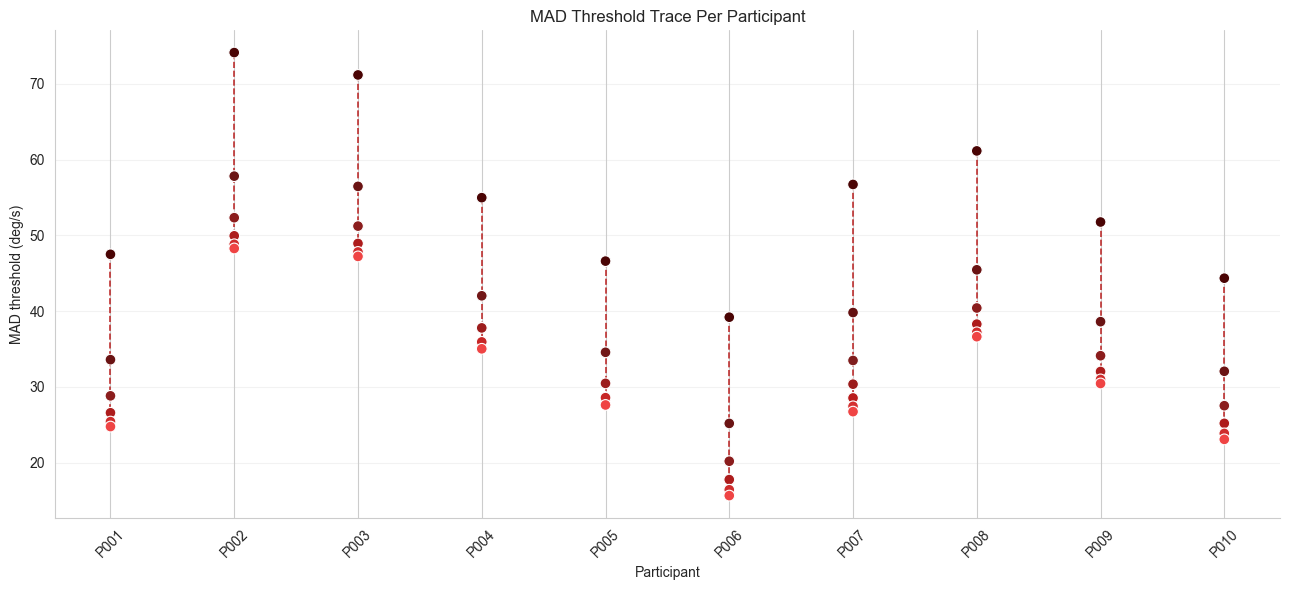

In [6]:
from matplotlib.colors import LinearSegmentedColormap

plt.figure(figsize=(13, 6))

trace_cmap = LinearSegmentedColormap.from_list(
    "mad_trace",
    ["#4a0404", "#7f1d1d", "#b91c1c", "#ef4444"],
)

for x, row in enumerate(threshold_summary.itertuples(index=False), start=1):
    trace = row.threshold_trace[1:]

    if not trace:
        continue

    x_vals = np.full(len(trace), x)
    point_colors = [trace_cmap(i / max(len(trace) - 1, 1)) for i in range(len(trace))]

    plt.plot(x_vals, trace, color="#b91c1c", linestyle="--", linewidth=1.2, alpha=0.9, zorder=1)
    plt.scatter(
        x_vals,
        trace,
        c=point_colors,
        s=60,
        marker="o",
        edgecolors="white",
        linewidth=0.8,
        zorder=3,
    )

plt.xticks(
    range(1, len(threshold_summary) + 1),
    [f"P{pid}" for pid in threshold_summary["participant_id"]],
    rotation=45,
)
plt.ylabel("MAD threshold (deg/s)")
plt.xlabel("Participant")
plt.title("MAD Threshold Trace Per Participant")
plt.grid(axis="y", alpha=0.25)
sns.despine()
plt.tight_layout()
plt.show()

In [18]:
threshold_summary[["participant_id", "mad_threshold", "n_rows", "n_valid_velocity_samples", "n_trace_steps"]]

,participant_id,mad_threshold,n_rows,n_valid_velocity_samples,n_trace_steps
0,001,24.770549,553478,547332,7
1,002,48.276827,493853,488814,7
2,003,47.229823,401153,366731,7
3,004,35.034193,561593,526027,6
4,005,27.621591,567598,557299,6
5,006,15.659925,563130,559833,7
6,007,26.740048,484199,474927,8
7,008,36.634737,374241,370182,7
8,009,30.455708,374904,368460,7
9,010,23.081091,511478,499679,7
